In [1]:
!pwd

/home/dayn/analysis/macrohetest/dev


In [10]:
# Standard library imports
import os
import warnings

# Third-party imports
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from tqdm.auto import tqdm  # Note: You might want to choose between tqdm or tqdm.auto

# Visualization imports
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib import gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Local imports
from macrohet import visualise, colours

# Setting visualization defaults
plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.size'] = 14
visualise.set_plotting_defaults()
expanded_piyg = colours.expanded_piyg

# Constants
meters_per_pixel = 1.4949402023919043E-07
micrometers_per_pixel = meters_per_pixel*1E6

Using Helvetica font.
Default plotting aesthetic loaded.


In [2]:
def replace_ytick_labels(ax, old_label, new_label):
    """
    Replace y-axis tick labels in a given matplotlib Axes object.
    
    Parameters:
    ax (matplotlib.axes.Axes): The axes on which to replace y-tick labels.
    old_label (str): The label to be replaced.
    new_label (str): The new label to replace the old label with.
    """
    # Get current y-tick labels
    yticks = ax.get_yticks()
    yticklabels = [label.get_text() for label in ax.get_yticklabels()]

    # Replace the old label with the new label
    yticklabels = [new_label if label == old_label else label for label in yticklabels]

    # Set the new y-tick labels
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

In [4]:
df = pd.read_pickle('/Volumes/OPERA2/Nathan/macrohet_syno/results/dfs/sc_df.pkl')
# df = pd.read_pickle('/mnt/SYNO/macrohet_syno/results/dfs/sc_df.pkl')
df['Video Link'] = df['ID'].apply(lambda ID: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/videos/{ID}_glimpse_graph.mp4")
# subset_df['Video Link'] = subset_df['ID'].apply(lambda ID: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/_BLOCK_{ID}_glimpse_graph.mp4")

In [7]:
df['Video Link'].iloc[0]

'https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/videos/1.3.2.ND0002_glimpse_graph.mp4'

### Params

In [6]:
### set plotting parameters
# Input figure size in millimeters
width_mm = 280  # for example, 180 mm
height_mm = 100  # for example, 80 mm
# Convert millimeters to inches (1 inch = 25.4 mm)
width_in = width_mm / 25.4
height_in = height_mm / 25.4

### set biological parameters
# Step 1: Bin the Doubling Times into categories
bins = [0, 16, 24, float('inf')]  # Define the bins: <20, 20-24, >24
labels = ['Fast', 'Normal', 'Slow']  # Labels for each bin
# Define the desired order with CTRL at the top
strain_order = ['CTRL', 'PZA', 'INH', 'RIF']

# Antibiotic growth

In [8]:
# Prepare the subset DataFrame, filtering for WT strain or CTRL with RD1
subset_df = df[((df['Strain'] == 'WT') | ((df['Strain'] == 'RD1') & (df['Compound'] == 'CTRL'))) 
             # & (df['r2'] >= 0.8) 
             & (df['Edge Status'] == False) 
             & (df['mtb_origin'] == 'Growth')  # are we really doing this right now? or after figure 3? 
              ].drop_duplicates(subset=['ID'])

# Continue with the usual process of exploding and filtering Doubling Times
subset_df = subset_df.explode('Doubling Times')
subset_df['Doubling Times'] = pd.to_numeric(subset_df['Doubling Times'], errors='coerce')
subset_df = subset_df[subset_df['Doubling Times'].notna()]
subset_df = subset_df[subset_df['Doubling Times'] > 0]
subset_df['Mtb Strain or Drug Compound'] = subset_df.apply(
    lambda row: 'CTRL' if row['Compound'] == 'CTRL' else row['Compound'], axis=1)
subset_df['CTRL Type'] = subset_df.apply(
    lambda row: row['Strain'] if row['Compound'] == 'CTRL' else None, axis=1)
print(f'N={len(subset_df)}')

N=728


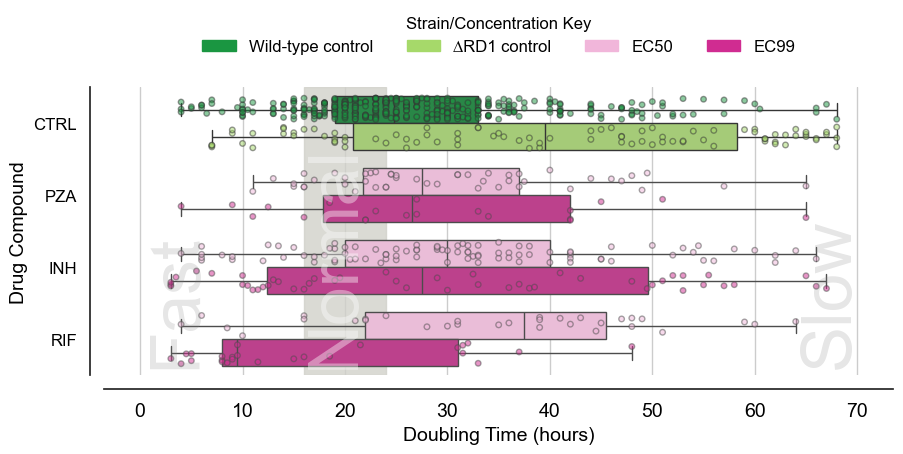

In [11]:
# Define the growth categories of the subset DataFrame
subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels= ['Fast', 'Normal', 'Slow'], right=False)
subset_df['Mtb Strain or Drug Compound'] = subset_df.apply(
    lambda row: 'CTRL' if row['Compound'] == 'CTRL' else row['Compound'], axis=1)
subset_df['CTRL Type'] = subset_df.apply(
    lambda row: row['Strain'] if row['Compound'] == 'CTRL' else None, axis=1)

# Initialize the figure with GridSpec
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])  # Main plot and bar chart sections

# Main Plot (left side)
ax = plt.subplot(gs[0])
for compound in ['CTRL', 'PZA', 'INH', 'RIF']:
    subset = subset_df[subset_df['Mtb Strain or Drug Compound'] == compound]
    available_concentrations = sorted(subset['Concentration'].unique())
    if compound == 'CTRL':
        sns.boxplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="CTRL Type",
            whis=[0, 100], width=.75, palette=[expanded_piyg[0], expanded_piyg[1]], ax=ax, order=strain_order
        )
        sns.stripplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="CTRL Type", size=4,
            edgecolor='auto', linewidth=1, jitter=0.3,
            palette=[expanded_piyg[0], expanded_piyg[1]], dodge=True, alpha=0.5, ax=ax, order=strain_order
        )
    else:
        palette = [expanded_piyg[4] if concentration == 'EC50' else expanded_piyg[5] for concentration in available_concentrations]
        sns.boxplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="Concentration",
            whis=[0, 100], width=.75, palette=palette, hue_order=available_concentrations, ax=ax, order=strain_order
        )
        sns.stripplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="Concentration", size=4,
            edgecolor='auto', linewidth=1, jitter=0.3,
            palette=palette, hue_order=available_concentrations, dodge=True, alpha=0.5, ax=ax, order=strain_order
        )

# Add legend and shaded regions
legend_handles = [
    mpatches.Patch(color=expanded_piyg[0], label='Wild-type control'),
    mpatches.Patch(color=expanded_piyg[1], label='∆RD1 control'),
    mpatches.Patch(color=expanded_piyg[4], label='EC50'),
    mpatches.Patch(color=expanded_piyg[5], label='EC99')
]
ax.legend(title='Strain/Concentration Key', handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4, frameon=False)
ax.axvspan(0, bins[1], color=expanded_piyg[3], alpha=0, label='Fast (<20h)')
ax.axvspan(bins[1], bins[2], color=expanded_piyg[3], alpha=0.8, label='Normal (20-28h)')
ax.axvspan(bins[2], 70, color=expanded_piyg[3], alpha=0, label='Slow (>28h)')

# Step 6: Add vertical text labels within each category region
ax.text(0+0.5, 3.2, 'Fast', fontsize=50, color='gray', alpha=0.2, ha='left', va='baseline', rotation=90)
ax.text(bins[1], 3.2, 'Normal', fontsize=50, color='white', alpha=0.4, ha='left', va='baseline', rotation=90)
ax.text(70.5, 3.2, 'Slow', fontsize=50, color='gray', alpha=0.2, ha='right', va='baseline', rotation=90)

ax.xaxis.grid(True)
replace_ytick_labels(ax, old_label='RD1', new_label='ΔRD1')

ax.set_xlabel('Doubling Time (hours)', fontsize=14)
ax.set_ylabel('Drug Compound', fontsize=14)
sns.despine(ax=ax, left=True) 
ax.tick_params(axis = 'x', left=False, labelsize = 14)

sns.despine(offset=10)

plt.tight_layout()
# plt.savefig('/mnt/SYNO/macrohet_syno/results/manuscript/f4/f4.pdf', bbox_inches='tight', dpi=314)
plt.show()


## Now integrate the bar plots to the left hand side

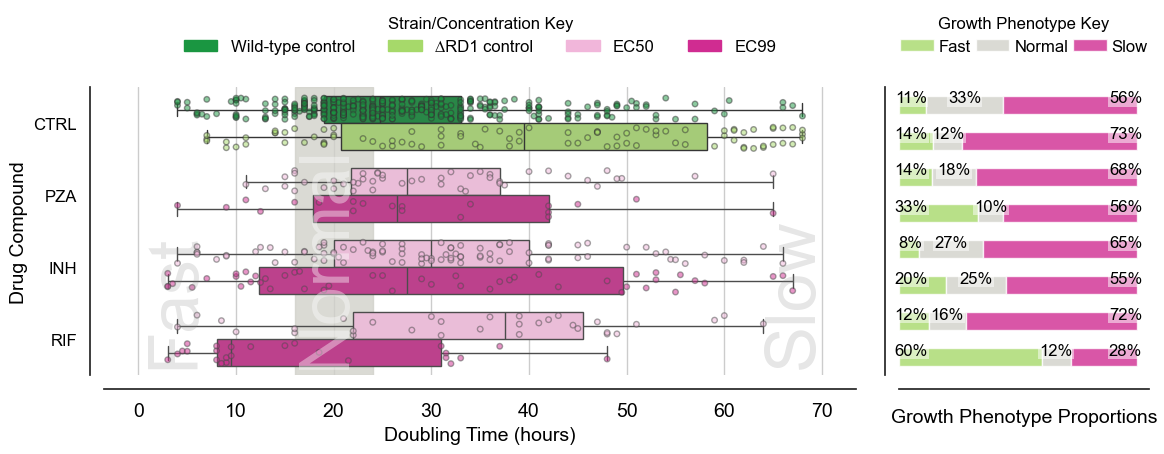

In [12]:
# Define the growth categories of the subset DataFrame
subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels= ['Fast', 'Normal', 'Slow'], right=False)
subset_df['Mtb Strain or Drug Compound'] = subset_df.apply(
    lambda row: 'CTRL' if row['Compound'] == 'CTRL' else row['Compound'], axis=1)
subset_df['CTRL Type'] = subset_df.apply(
    lambda row: row['Strain'] if row['Compound'] == 'CTRL' else None, axis=1)

# Initialize the figure with GridSpec
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])  # Main plot and bar chart sections

# Main Plot (left side)
ax = plt.subplot(gs[0])
for compound in ['CTRL', 'PZA', 'INH', 'RIF']:
    subset = subset_df[subset_df['Mtb Strain or Drug Compound'] == compound]
    available_concentrations = sorted(subset['Concentration'].unique())
    if compound == 'CTRL':
        sns.boxplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="CTRL Type",
            whis=[0, 100], width=.75, palette=[expanded_piyg[0], expanded_piyg[1]], ax=ax, order=strain_order
        )
        sns.stripplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="CTRL Type", size=4,
            edgecolor='auto', linewidth=1, jitter=0.3,
            palette=[expanded_piyg[0], expanded_piyg[1]], dodge=True, alpha=0.5, ax=ax, order=strain_order
        )
    else:
        palette = [expanded_piyg[4] if concentration == 'EC50' else expanded_piyg[5] for concentration in available_concentrations]
        sns.boxplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="Concentration",
            whis=[0, 100], width=.75, palette=palette, hue_order=available_concentrations, ax=ax, order=strain_order
        )
        sns.stripplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="Concentration", size=4,
            edgecolor='auto', linewidth=1, jitter=0.3,
            palette=palette, hue_order=available_concentrations, dodge=True, alpha=0.5, ax=ax, order=strain_order
        )

# Add legend and shaded regions
legend_handles = [
    mpatches.Patch(color=expanded_piyg[0], label='Wild-type control'),
    mpatches.Patch(color=expanded_piyg[1], label='∆RD1 control'),
    mpatches.Patch(color=expanded_piyg[4], label='EC50'),
    mpatches.Patch(color=expanded_piyg[5], label='EC99')
]
ax.legend(title='Strain/Concentration Key', handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4, frameon=False)
ax.axvspan(0, bins[1], color=expanded_piyg[3], alpha=0, label='Fast (<20h)')
ax.axvspan(bins[1], bins[2], color=expanded_piyg[3], alpha=0.8, label='Normal (20-28h)')
ax.axvspan(bins[2], 70, color=expanded_piyg[3], alpha=0, label='Slow (>28h)')

# Step 6: Add vertical text labels within each category region
ax.text(0+0.5, 3.2, 'Fast', fontsize=50, color='gray', alpha=0.2, ha='left', va='baseline', rotation=90)
ax.text(bins[1], 3.2, 'Normal', fontsize=50, color='white', alpha=0.4, ha='left', va='baseline', rotation=90)
ax.text(70.5, 3.2, 'Slow', fontsize=50, color='gray', alpha=0.2, ha='right', va='baseline', rotation=90)

ax.xaxis.grid(True)
replace_ytick_labels(ax, old_label='RD1', new_label='ΔRD1')

ax.set_xlabel('Doubling Time (hours)', fontsize=14)
ax.set_ylabel('Drug Compound', fontsize=14)
sns.despine(ax=ax, left=True) 
ax.tick_params(axis = 'x', left=False, labelsize = 14)
############################################# porportion plots #################################################################

# Right Plot: Stacked Bar Charts for CTRL and Antibiotics
ctrl_counts = subset_df[subset_df['Compound'] == 'CTRL'].groupby(['CTRL Type', 'Growth Category'], observed=False).size().unstack(fill_value=0)
ctrl_percentages = ctrl_counts.div(ctrl_counts.sum(axis=1), axis=0).reset_index().iloc[::-1]
ctrl_percentages['Compound'] = ctrl_percentages['CTRL Type']  # Add a common column for consistency

# Antibiotics Data: Ensure concentration is part of the final DataFrame
antibiotics_counts = subset_df[subset_df['Compound'] != 'CTRL'].groupby(
    ['Compound', 'Concentration', 'Growth Category'],  observed=False
).size().unstack(fill_value=0)

# Reset the index to include 'Compound' and 'Concentration' as columns
antibiotics_df = antibiotics_counts.reset_index()

# Normalize the antibiotics counts
antibiotics_df.set_index(['Compound', 'Concentration'], inplace=True)
antibiotics_percentages = antibiotics_df.div(antibiotics_df.sum(axis=1), axis=0).reset_index()
antibiotics_percentages['Compound'] = antibiotics_percentages['Compound'] + ' - ' + antibiotics_percentages['Concentration']

# Concatenate the two datasets
combined_data = pd.concat(
    [ctrl_percentages.set_index('Compound').drop(columns=['CTRL Type']),
     antibiotics_percentages.set_index('Compound').drop(columns=['Concentration'])],
    axis=0
)

# Normalize combined data
combined_data = combined_data.div(combined_data.sum(axis=1), axis=0).iloc[::-1]

# Plot combined data
ax2 = plt.subplot(gs[1])
combined_data.plot(
    kind='barh', stacked=True, ax=ax2, color=[expanded_piyg[1], expanded_piyg[3], expanded_piyg[5]], alpha=0.8
)
# Customizing bar chart
ax2.set_ylabel('')
ax2.legend(title='Growth Phenotype Key', bbox_to_anchor=(0.5, 1.3), loc='upper center', frameon=False, ncol = 3, 
                   handletextpad=0.3,  # Reduce space between legend marker and text
                    columnspacing=0.3)   # Reduce space between columns)
sns.despine(ax=ax2, right=True) #left = False, right = True, bottom = True)
ax2.set_ylabel('')
ax2.set_yticklabels([])
ax2.set_xticklabels([])
ax2.set_xlabel('Growth Phenotype Proportions', fontsize=14)

for i, container in enumerate(ax2.containers):
    x_positions = [0.05, 0.5, 0.95]  # Fixed x positions for left, middle, and right segments (normalized to the axis range)    
    for j, bar in enumerate(container):
        width = bar.get_width()  # Get the width of the current bar
        if width > 0:  # Only add labels for non-zero bars
            if i==1:
                x = bar.get_x() + width / 2 
            else:
                x = x_positions[i % 3]  # Assign x position based on fixed positions
            y = bar.get_y() + bar.get_height() / 2 + 0.2  # Center vertically with offset
            percentage = f"{round(width * 100):d}%"  # Format percentage rounded to an integer
            ax2.text(x, y, percentage, ha='center', va='center', fontsize=12, color='black', 
                     bbox=dict(facecolor='white', edgecolor='none', pad=1, alpha =0.5))

sns.despine(offset=10)

plt.tight_layout()
plt.show()


# Interactive F4

In [38]:
combined_data

Growth Category,Fast,Normal,Slow
Compound,,,
RIF - EC99,0.600000,0.120000,0.280000
RIF - EC50,0.125000,0.156250,0.718750
PZA - EC99,0.200000,0.250000,0.550000
PZA - EC50,0.083333,0.270833,0.645833
INH - EC99,0.333333,0.104167,0.562500
INH - EC50,0.139785,0.182796,0.677419
RD1,0.144444,0.122222,0.733333
WT,0.112903,0.325269,0.561828


In [29]:
marker_colors = {
    'CTRL': expanded_piyg[0],
    'RD1': expanded_piyg[1],
    'EC50': expanded_piyg[-2],
    'EC99': expanded_piyg[-1],
    'Fast': 'white',#'rgba(0, 128, 0, 0.2)',
    'Normal': expanded_piyg[3], #'rgba(255, 255, 0, 0.4)',
    'Slow': 'white',#'rgba(255, 0, 0, 0.2)',
}
scaling_factor = 1.5
vertical_offset = 0.31
# Colors for the plot
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']  # Custom color palette
colors = {
    'WT': expanded_piyg[0],
    'RD1': expanded_piyg[1],
  'EC50': expanded_piyg[-2],
    'EC99': expanded_piyg[-1],
    'Fast': 'white',#'rgba(0, 128, 0, 0.2)',
    'Normal': expanded_piyg[3], #'rgba(255, 255, 0, 0.4)',
    'Slow': 'white',#'rgba(255, 0, 0, 0.2)',
}
# colors = {'WT':expanded_piyg[1], 'RD1':expanded_piyg[-1],   'Fast':expanded_piyg[0], 'Normal':expanded_piyg[3], 'Slow':expanded_piyg[-1]}

# Define the strain order and color palette
strain_order = ['CTRL', 'PZA', 'INH', 'RIF']  # Define the order of compounds
# reverse the order and create cat mappin
categories = subset_df['Mtb Strain or Drug Compound'].unique()[::-1]
# Update category mapping to include scaling factor
category_mapping = {category: i * scaling_factor for i, category in enumerate(categories)}

# Define vertical offsets for concentrations and CTRL types
vertical_offsets = {
    'EC50': vertical_offset,    # Shift EC50 up
    'EC99': -vertical_offset,   # Shift EC99 down
    'WT': vertical_offset,      # Shift WT slightly up
    'RD1': -vertical_offset     # Shift RD1 slightly down
}

# Legend entries configuration
legend_entries = [
    {"color": colors['WT'], "name": "Wild-type control"},
    {"color": colors['RD1'], "name": "ΔRD1 control"},
    {"color": colors['EC50'], "name": "EC50"},
    {"color": colors['EC99'], "name": "EC99"}
]


In [80]:
combined_data

Growth Category,Compound,Fast,Normal,Slow
0,RIF - EC99,0.600000,0.120000,0.280000
1,RIF - EC50,0.125000,0.156250,0.718750
2,INH - EC99,0.333333,0.104167,0.562500
3,INH - EC50,0.139785,0.182796,0.677419
4,PZA - EC99,0.200000,0.250000,0.550000
5,PZA - EC50,0.083333,0.270833,0.645833
6,RD1,0.144444,0.122222,0.733333
7,WT,0.112903,0.325269,0.561828


In [196]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Step 1: Categorize growth into bins
subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels=['Fast', 'Normal', 'Slow'], right=False)

# Step 2: Compute proportions for control and antibiotic-treated groups
ctrl_counts = subset_df[subset_df['Compound'] == 'CTRL'].groupby(['CTRL Type', 'Growth Category']).size().unstack(fill_value=0)
ctrl_percentages = ctrl_counts.div(ctrl_counts.sum(axis=1), axis=0).reset_index()

antibiotic_counts = subset_df[subset_df['Compound'] != 'CTRL'].groupby(['Compound', 'Concentration', 'Growth Category']).size().unstack(fill_value=0)
antibiotic_percentages = antibiotic_counts.div(antibiotic_counts.sum(axis=1), axis=0).reset_index()

# Combine control and antibiotic data
ctrl_percentages['Compound'] = ctrl_percentages['CTRL Type']
antibiotic_percentages['Compound'] = antibiotic_percentages['Compound'] + ' - ' + antibiotic_percentages['Concentration']

# Merge all into one dataframe for plotting
combined_data = pd.concat([ctrl_percentages.set_index('Compound').drop(columns=['CTRL Type']),
                           antibiotic_percentages.set_index('Compound').drop(columns=['Concentration'])])

combined_data = combined_data.iloc[::-1]  # Flip order for readability

# Reset the index to flatten the DataFrame
combined_data = combined_data.reset_index()

# Define the desired order
desired_order = list(reversed(["WT", "RD1", "PZA - EC50", "PZA - EC99", "INH - EC50", "INH - EC99", "RIF - EC50", "RIF - EC99"]))

# Reorder the dataframe based on desired order
combined_data = combined_data.set_index("Compound").loc[desired_order].reset_index()

combined_data.fillna(0, inplace=True)

# Ensure the Growth Category columns are named correctly
if isinstance(combined_data.columns, pd.MultiIndex):
    combined_data.columns = combined_data.columns.get_level_values(0)  # Flatten MultiIndex columns

# Define custom y-axis positions with gaps for grouping
grouped_y_positions = {
    "WT": 4.75,
    "RD1": 4.25,  # Closer to WT

    "PZA - EC50": 3.25,
    "PZA - EC99": 2.75,  # Closer to EC50

    "INH - EC50": 1.75,
    "INH - EC99": 1.25,  # Closer to EC50

    "RIF - EC50": 0.25,
    "RIF - EC99": -0.25  # Closer to EC50
}

# Apply these positions to `combined_data`
combined_data["y_position"] = combined_data["Compound"].map(grouped_y_positions)

# Step 3: Define colors for the stacked bars
category_colors = {
    "Fast": expanded_piyg[1],    
    "Normal": expanded_piyg[3], 
    "Slow": expanded_piyg[-1]
}

# Step 4: Create the interactive subplots
fig = make_subplots(
    rows=1, cols=2, 
    column_widths=[0.7, 0.3],   # Adjust size ratio of plots (Main plot: 70%, Bar chart: 30%)
    shared_yaxes=True,          # Sync y-axis between plots
    horizontal_spacing=0.05,     # Reduce space between plots
    subplot_titles=("", "")
)

### 🔹 **Left Plot: Boxplots & Scatter (Existing Code)**
for compound in ['CTRL', 'PZA', 'INH', 'RIF']:
    compound_data = subset_df[subset_df['Mtb Strain or Drug Compound'] == compound]
    concentrations = compound_data['Concentration'].unique()
    ctrl_types = compound_data['CTRL Type'].unique() if compound == 'CTRL' else [None]

    for ctrl_type in ctrl_types:
        ctrl_type_data = compound_data[compound_data['CTRL Type'] == ctrl_type] if ctrl_type else compound_data

        for concentration in concentrations:
            data = ctrl_type_data[ctrl_type_data['Concentration'] == concentration]
            if data.empty:
                continue

            color = colors.get(ctrl_type if compound == 'CTRL' else concentration, 'gray')
            y_position = category_mapping[compound] + vertical_offsets.get(ctrl_type, 0) + vertical_offsets.get(concentration, 0)
            jitter = np.random.uniform(-vertical_offset*0.8, vertical_offset*0.8, size=len(data))

            # Boxplot trace
            fig.add_trace(go.Box(
                x=data['Doubling Times'], y=[y_position] * len(data), hoverinfo="none",
                marker_color=color, boxmean=False, orientation="h", width=0.6, boxpoints=False, showlegend=False
            ), row=1, col=1,      # This removes IQR and mean from hover)
                         )
            # Scatter points with video links
            fig.add_trace(go.Scatter(
                x=data['Doubling Times'], y=[y_position + jitter[i] for i in range(len(data))],
                mode="markers", marker=dict(color=color, size=8, opacity=0.6, line=dict(color='gray', width=1)),
                customdata=data['Video Link'],
                hoverinfo="text",
                text=[f"<b>Doubling Time:</b> {x:.2f}<br><b>Treatment:</b>{compound} {ctrl_type or ''}{'' if concentration == 'EC0' else concentration or ''}<br>" for x in data['Doubling Times']],
                showlegend=False
            ), row=1, col=1)

for category in expected_categories:
    fig.add_trace(go.Bar(
        y=combined_data["y_position"],  # Use custom y positions
        x=combined_data[category],
        name=category,
        marker=dict(color=category_colors[category]),
        orientation="h",
        hovertext=[f"Strain/Compound: {compound}<br>{category} Proportion: {v*100:.1f}%"
                   for compound, v in zip(combined_data["Compound"], combined_data[category])],
        hoverinfo="text",
        text=[f"{v*100:.1f}%" if v > 0 else "" for v in combined_data[category]],  
        textposition="inside",
        insidetextanchor="middle",
        width=0.5 # Reduce width slightly for clarity
    ), row=1, col=2)

    
fig.update_layout(
    height=600,
    width=1100,
    showlegend=True,
    legend=dict(
        title=dict(
            text="         Growth Categories",
            side="top",
            font=dict(family="Helvetica")  # Ensure legend title is Helvetica
        ),
        orientation="h",
        xanchor="center",
        x=0.85,
        yanchor="bottom",
        y=1.0,
        tracegroupgap=5,
        itemwidth=30,
        font=dict(family="Helvetica", size=16)  # Ensure legend items are Helvetica
    ),
    hovermode="closest",
    title=dict(
        text="Fast-growing intracellular Mtb evades antibiotic treatment",
        font=dict(family="Helvetica", size=24, weight='bold')  # Ensure main title is Helvetica
    ),
    template="plotly_white",
    
    # Left plot axis settings
    xaxis=dict(
        title="Doubling Time (hours)",
        gridcolor="rgba(200,200,200,0.3)",
        tickmode="linear",
        dtick=10,
        title_font=dict(family="Helvetica", size=16),  # Ensure x-axis title is Helvetica
        tickfont=dict(family="Helvetica", size=16)  # Ensure x-axis tick labels are Helvetica
    ),
    yaxis=dict(
        title="Drug Compound",
        tickvals=[category_mapping[compound] for compound in category_mapping.keys()],
        ticktext=list(category_mapping.keys()),
        title_font=dict(family="Helvetica", size=16),  # Ensure y-axis title is Helvetica
        tickfont=dict(family="Helvetica", size=16)  # Ensure y-axis tick labels are Helvetica
    ),

    # Right plot axis settings
    xaxis2=dict(
        title="Growth Phenotype Proportions",
        tickvals=[],
        showgrid=False,  # Hide gridlines
        zeroline=False,  # Remove the vertical line at x=0
        showline=False,  # Ensure no axis line is drawn
        title_font=dict(family="Helvetica", size=16),  # Ensure x-axis title is Helvetica
        tickfont=dict(family="Helvetica", size=16)  # Ensure x-axis tick labels are Helvetica
    ),
    yaxis2=dict(
        tickvals=[0, 1, 2],
        ticktext=["Fast", "Normal", "Slow"],
        title_font=dict(family="Helvetica", size=16),  # Ensure y-axis title is Helvetica
        tickfont=dict(family="Helvetica", size=16),
        showgrid=False, showticklabels=False
    ),
    barmode="stack",
    font=dict(family="Helvetica")  # Ensure Helvetica is the default font everywhere
)
# Thick line under the Box Plot (Left Plot)
fig.add_shape(
    type="line",
    x0=0, x1=0.66,  # Constrained to the left plot
    xref="paper",
    y0=-0, y1=-0,  # Slightly below the lowest y-axis
    yref="paper",
    line=dict(color="black", width=2),
    layer="above"
)

# Thick line under the Bar Chart (Right Plot)
fig.add_shape(
    type="line",
    x0=0.71, x1=0.99,  # Constrained to the right plot
    xref="paper",
    y0=-0, y1=-0,  # Slightly below the lowest y-axis
    yref="paper",
    line=dict(color="black", width=2),
    layer="above"
)

# Add annotations for categories
fig.add_annotation(text="Fast", x=0, y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(0, 0, 0, 0.2)", family="Helvetica"), xanchor="left", yanchor="bottom")
fig.add_annotation(text="Normal", x=bins[1], y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(255, 255, 255, 0.5)", family="Helvetica"), xanchor="left", yanchor="bottom")
fig.add_annotation(text="Slow", x=70, y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(0, 0, 0, 0.2)", family="Helvetica"), xanchor="right", yanchor="bottom")

# Add shaded region to the first subplot
fig.add_shape(
    type="rect", 
    x0=bins[1], x1=bins[2], 
    y0=-0.75, y1=5.5, 
    fillcolor=colors['Normal'], 
    opacity=0.4, 
    layer="below", 
    line_width=0,
    row=1, col=1
)

grouped_y_positions = {
    "WT": 4.75,
    "RD1": 4.25,  # Closer to WT

    "PZA - EC50": 3.25,
    "PZA - EC99": 2.75,  # Closer to EC50

    "INH - EC50": 1.75,
    "INH - EC99": 1.25,  # Closer to EC50

    "RIF - EC50": 0.25,
    "RIF - EC99": -0.25  # Closer to EC50
}



stat_significance = [
    # Original lines
    {"y1": 4, "y2": 5, "x": 71, "text": "***"},   # Between 72 & 74
    {"y1": 3.3, "y2": 5, "x": 72, "text": ".ns"},  # PZA EC50 vs EC99
    {"y1": 2.6, "y2": 5, "x": 73, "text": ".ns"},  # Between 74 & 76
    {"y1": 1.65, "y2": 5, "x": 74, "text": ".ns"},    # INH EC50 vs EC99
    {"y1": 1, "y2": 5, "x": 75, "text": "**"},    # Between 76 & 78
    {"y1": 0.25, "y2": 5, "x": 76, "text": "**"}, # RIF EC50 vs EC99
    {"y1": -0.5, "y2": 5, "x": 77, "text": "***"}  # Between 78 & 80
]
for stat in stat_significance:
    fig.add_shape(
        type="line",
        x0=stat["x"], x1=stat["x"],  # Keeps the line vertical
        y0=stat["y1"], y1=stat["y2"],  # Defines start and end of the line
        xref="x1",  # Reference full figure width
        yref="y1",  # Reference y-axis of the second plot (bar chart)
        line=dict(color="black", width=1)  # Style of the significance line
    )

    # Add text annotation above the line
    fig.add_annotation(
        x=stat["x"]-1, y=stat["y1"]+0.01,  # Position text slightly above line
        text=stat["text"],
        showarrow=False,
        font=dict(size=14, family="Helvetica", color="black"),
        xanchor="center",
        yanchor="bottom",
        textangle=270  # Rotate the text 90 degrees
    )
stat_significance = [
    {"y1": 4, "y2": 5, "x": 1.15, "text": "***"},   # Between 72 & 74
    {"y1": 3.3, "y2": 5, "x": 1.19, "text": ".ns"},  # PZA EC50 vs EC99
    {"y1": 2.6, "y2": 5, "x": 1.23, "text": ".ns"},  # Between 74 & 76
    {"y1": 1.65, "y2": 5, "x": 1.27, "text": "***"},    # INH EC50 vs EC99
    {"y1": 1, "y2": 5, "x": 1.31, "text": ".ns"},    # Between 76 & 78
    {"y1": 0.25, "y2": 5, "x": 1.35, "text": "***"}, # RIF EC50 vs EC99
    {"y1": -0.5, "y2": 5, "x": 1.39, "text": "***"}  # Between 78 & 80
]
for stat in stat_significance:
    fig.add_shape(
        type="line",
        x0=stat["x"], x1=stat["x"],  # Keeps the line vertical
        y0=stat["y1"], y1=stat["y2"],  # Defines start and end of the line
        xref="x2",  # Reference full figure width
        yref="y2",  # Reference y-axis of the second plot (bar chart)
        line=dict(color="black", width=1)  # Style of the significance line
    )

    # Add text annotation above the line
    fig.add_annotation(
        x=stat["x"]-0.05, y=stat["y1"],  # Position text slightly above line
        text=stat["text"],
        showarrow=False,
        font=dict(size=14, family="Helvetica", color="black"),
        xanchor="center",
        yanchor="bottom",
        xref="x2",  # Reference full figure width
        yref="y2",  # Reference y-axis of the second plot (bar chart)
        textangle=270  # Rotate the text 90 degrees
    )
    
# Show figure
fig.show(renderer="iframe")

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_94415/2393211135.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_94415/2393211135.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [37]:
# Initialize the subplot figure
fig = make_subplots(
    rows=2, 
    cols=2,
    column_widths=[0.8, 0.2],
    row_heights=[0.95, 0.05],
    horizontal_spacing=0.01,
    vertical_spacing=0.01
)

# Add shaded region to the first subplot
fig.add_shape(
    type="rect", 
    x0=bins[1], x1=bins[2], 
    y0=-0.75, y1=5.5, 
    fillcolor=colors['Normal'], 
    opacity=0.4, 
    layer="below", 
    line_width=0,
    row=1, col=1
)
# Add annotations for categories
fig.add_annotation(text="Fast", x=0, y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(0, 0, 0, 0.2)", family="Helvetica"), xanchor="left", yanchor="bottom")
fig.add_annotation(text="Normal", x=bins[1], y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(255, 255, 255, 0.5)", family="Helvetica"), xanchor="left", yanchor="bottom")
fig.add_annotation(text="Slow", x=70, y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(0, 0, 0, 0.2)", family="Helvetica"), xanchor="right", yanchor="bottom")



# Add your existing boxplots and scatter points to the first subplot
for compound in ['CTRL', 'PZA', 'INH', 'RIF']:
    compound_data = subset_df[subset_df['Mtb Strain or Drug Compound'] == compound]
    concentrations = compound_data['Concentration'].unique()
    ctrl_types = compound_data['CTRL Type'].unique() if compound == 'CTRL' else [None]

    for ctrl_type in ctrl_types:
        ctrl_type_data = compound_data[compound_data['CTRL Type'] == ctrl_type] if ctrl_type else compound_data

        for concentration in concentrations:
            data = ctrl_type_data[ctrl_type_data['Concentration'] == concentration]

            if data.empty:
                continue

            # Your existing color logic
            if compound == 'CTRL':
                color = colors.get(ctrl_type, 'gray')
            else:
                color = colors.get(concentration, 'gray')

            base_y_position = category_mapping[compound]
            y_position = base_y_position + vertical_offsets.get(ctrl_type, 0) + vertical_offsets.get(concentration, 0)
            jitter = np.random.uniform(-vertical_offset*0.8, vertical_offset*0.8, size=len(data))

            # Add traces to first subplot
            fig.add_trace(
                go.Box(
                    x=data['Doubling Times'],
                    y=[y_position] * len(data),
                    name=f"{compound} - {ctrl_type or ''} - {concentration or ''}".strip(" - "),
                    marker_color=color,
                    boxmean=False,
                    orientation="h",
                    width=0.6,
                    boxpoints=False,
                    showlegend=False,
                    hoverinfo='skip'
                ),
                row=1, col=1
            )

            fig.add_trace(
                go.Scatter(
                    x=data['Doubling Times'],
                    y=[y_position + jitter[i] for i in range(len(data))],
                    mode="markers",
                    name=f"{compound} {ctrl_type or ''} {'' if concentration == 'EC0' else concentration or ''}".strip(),
                    marker=dict(
                        color=color, 
                        size=8, 
                        opacity=0.6, 
                        line=dict(color='gray', width=1)
                    ),
                    customdata=data['Video Link'],
                    hoverinfo="text",
                    text=[
                        f"<b>Doubling Time:</b> {x:.2f}<br><b>Treatment:</b>{compound} {ctrl_type or ''}{'' if concentration == 'EC0' else concentration or ''}<br>"
                        for x in data['Doubling Times']
                    ],
                    showlegend=False
                ),
                row=1, col=1
            )

# Add the proportions to the second subplot
growth_categories = ['Fast', 'Normal', 'Slow']
colors_bar = [expanded_piyg[1], expanded_piyg[3], expanded_piyg[5]]

for i, (category, color) in enumerate(zip(growth_categories, colors_bar)):
    fig.add_trace(
        go.Bar(
            x=combined_data[category],
            y=combined_data['Category'],
            name=category,
            orientation='h',
            marker_color=color,
            opacity=0.8,
            text=[f"{val:.0%}" if val > 0.05 else "" for val in combined_data[category]],
            textposition='inside',
            textfont=dict(color='black', size=12),
            showlegend=True,
            legendgroup=category,
        ),
        row=1, col=2
    )

# Update layout
fig.update_layout(
    # Your existing layout settings
    barmode='stack',
    template="plotly_white",
    height=600,
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    )
)

# Update axes
fig.update_xaxes(visible=False, range=[0, 1], row=1, col=2)
fig.update_yaxes(visible=False, row=1, col=2)

fig.show(renderer="iframe")

KeyError: 'Category'

In [39]:
combined_data

Growth Category,Fast,Normal,Slow
Compound,,,
RIF - EC99,0.600000,0.120000,0.280000
RIF - EC50,0.125000,0.156250,0.718750
PZA - EC99,0.200000,0.250000,0.550000
PZA - EC50,0.083333,0.270833,0.645833
INH - EC99,0.333333,0.104167,0.562500
INH - EC50,0.139785,0.182796,0.677419
RD1,0.144444,0.122222,0.733333
WT,0.112903,0.325269,0.561828


In [198]:
import json
import numpy as np

def is_numeric(x):
    """Check if a value is numeric and can be tested for NaN"""
    return isinstance(x, (int, float, np.integer, np.floating))

def convert_to_serializable(obj):
    """
    Recursively convert non-serializable objects to serializable types,
    handling NaN values properly
    """
    if isinstance(obj, np.ndarray):
        # Handle arrays depending on their dtype
        if np.issubdtype(obj.dtype, np.number):
            return [None if (is_numeric(x) and np.isnan(x)) else x 
                   for x in obj.tolist()]
        return obj.tolist()
    
    elif isinstance(obj, (np.integer, np.floating)):
        if np.isnan(obj):
            return None
        return float(obj)
    
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    
    elif hasattr(obj, 'to_plotly_json'):
        return convert_to_serializable(obj.to_plotly_json())
    
    # Handle other numeric types that might be NaN
    elif is_numeric(obj):
        if np.isnan(obj):
            return None
        return float(obj) if isinstance(obj, (np.integer, np.floating)) else obj
    
    return obj

def export_figure_to_json(fig, output_path):
    """
    Export a single figure to JSON with proper NaN handling
    """
    figure_data = {
        'data': [],
        'layout': convert_to_serializable(fig.layout)
    }
    
    for trace in fig.data:
        converted_trace = convert_to_serializable(trace)
        figure_data['data'].append(converted_trace)
        
    with open(output_path, 'w') as f:
        json.dump(figure_data, f, indent=2)

# # Export the boxplot
export_figure_to_json(fig, '../docs/figures/data/F4B_plot_data.json')

In [19]:
html_template = f"""
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        .container {{
            margin: 0 auto;
        }}
        #plot {{
            height: 10vh;
        }}
        .hover-popup {{
            position: absolute;
            background-color: white;
            border: 2px solid white;
            padding: 5px;
            z-index: 1000;
            display: none;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
    </style>
</head>
<body>
    <div class="container">
        <div id="plot"></div>
        <div id="hover-popup" class="hover-popup">
            <video id="popup-video" 
                   style="width: 400px; height: 400px; object-fit: cover; object-position: center top;" 
                   autoplay loop muted playsinline>
            </video>
        </div>
    </div>
    <script>
        // Load the Plotly figure
        const figure = {fig.to_json()};
        
        // Initialize the plot
        Plotly.newPlot('plot', figure.data, figure.layout);
        
        const hoverPopup = document.getElementById('hover-popup');
        const popupVideo = document.getElementById('popup-video');
        
        // Add hover event listener for plot
        document.getElementById('plot').on('plotly_hover', function(eventData) {{
            const point = eventData.points[0];
            const videoUrl = point.customdata;
            
            if (videoUrl) {{
                // Update video source and show popup
                popupVideo.src = videoUrl;
                hoverPopup.style.display = 'block';
                
                // Position the popup near the cursor
                const hoverWidth = hoverPopup.offsetWidth;
                hoverPopup.style.left = `${{eventData.event.clientX - hoverWidth/2}}px`;
                hoverPopup.style.top = `${{eventData.event.clientY + 20}}px`;
            }}
        }});
        
        // Hide popup on unhover
        document.getElementById('plot').on('plotly_unhover', function() {{
            hoverPopup.style.display = 'none';
            popupVideo.pause();
        }});
    </script>
</body>
</html>
"""

# Save the plot to an HTML file with added video functionality
output_file = "interactive_plots/F4_.html"

# Write the HTML file
with open(output_file, "w") as f:
    f.write(html_template)

print(f"Interactive plot with video hover saved to {output_file}")
# Open in browser
webbrowser.open('file://' + os.path.realpath(output_file))

Interactive plot with video hover saved to interactive_plots/F4_.html


NameError: name 'webbrowser' is not defined

### Save out the html to the main webpage

In [45]:

# Save the plot to an HTML file with added video functionality
output_file = "../docs/figures/F4.html"

# Write the HTML file
with open(output_file, "w") as f:
    f.write(html_template)

print(f"Interactive plot with video hover saved to {output_file}")
# Open in browser
webbrowser.open('file://' + os.path.realpath(output_file))

Interactive plot with video hover saved to ../docs/figures/F4.html


True